In [128]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
from scipy import stats
from scipy.stats import pearsonr, chi2_contingency
import statsmodels.api as sm
from sklearn.preprocessing import OneHotEncoder

df_base = pd.read_csv('DTP_DATA_2025.csv')
# база большая
df_prbase = pd.read_csv('DTP_DATA_2025_PROCESSED.csv')
# база малая обработанная
df_merge = pd.merge(df_prbase, df_base[['ID', 'road_defects', 'road_rank', 'lighting', "TYPE",
                                        'site_objects', 'adj_objects', 'cause_factors']],
                    on='ID', how='left').drop(columns = 'Unnamed: 0')
# объединяем

In [129]:
def bootstrap(X, y, model, n_bootstrap, sample_size, alpha = 0.05):
    warnings.filterwarnings('ignore')
    cols = X.columns.tolist()
    n_obs = len(X)
    coefs = pd.DataFrame(np.zeros((n_bootstrap, len(cols))), columns=cols)
    pvalues = pd.DataFrame(np.zeros((n_bootstrap, len(cols))), columns=cols)
    failed_samples = 0


    for i in tqdm(range(n_bootstrap), desc='bootstrap итерации'):
        
        sample_indices = np.random.choice(n_obs, size=sample_size, replace=True)
        y_sample = y.iloc[sample_indices].copy()
        X_sample = X.iloc[sample_indices].copy().astype(float)
        
        constant_cols = X_sample.columns[X_sample.nunique() <= 1]
        X_sample = X_sample.drop(columns=constant_cols)
        X_sample = sm.add_constant(X_sample)

        try:
            model_sample = model(y_sample, X_sample).fit(disp=False, maxiter=200)

            for col in cols:
                if col in constant_cols:
                    coefs[col][i] = np.nan
                    pvalues[col][i] = np.nan
                else:
                    coefs[col][i] = model_sample.params[col]
                    pvalues[col][i] = model_sample.pvalues.get(col, np.nan)

        except Exception as e:
            failed_samples += 1
            for col in cols:
                coefs[col][i] = np.nan
                pvalues[col][i] = np.nan

    return coefs, pvalues, failed_samples



In [130]:
def bootstrap_stats(coefs, pvalues, alpha = 0.05):
    cols = coefs.columns.tolist()
    stats = pd.DataFrame(index = cols,
                         columns=[f'{alpha * 50}', f'{100 - alpha * 50}', 'mean', 'std', f'pvalues > {alpha}']
                        )
    for col in cols:
        lcoef = [c for c in coefs[col].tolist() if not np.isnan(c)]
        lpvalue = [p for p in pvalues[col].tolist() if not np.isnan(p)]
        stats[f'{alpha * 50}'][col] = np.percentile(lcoef, 50 * alpha)
        stats[f'{100 - alpha * 50}'][col] = np.percentile(lcoef, (100 - alpha * 50))
        stats['mean'][col] = np.mean(lcoef)
        stats['std'][col] = np.std(lcoef)
        stats[f'pvalues > {alpha}'][col] = sum([1 if p > alpha else 0 for p in lpvalue])
    return stats



In [131]:
def bootstrap_visual(coefs, cols_visual, alpha=0.05, stats=None):
    n = len(cols_visual)
    if n == 1:
        i = 0
        plt.figure(figsize=(8, 8))
        plt.hist(coefs[cols_visual[i]], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        plt.ylabel('Частота')
        plt.xlabel(f'Коэффициент при {cols_visual[i]}')
        plt.title(f'Распределение коэффициента {cols_visual[i]}')

        if stats is not None:
            plt.axvline(stats['mean'][cols_visual[i]],
                            color='red', linestyle='--', linewidth=2,
                            label=f'Среднее: {stats['mean'][cols_visual[i]]:.4f}')

            plt.axvline(stats[f'{alpha * 50}'][cols_visual[i]],
                                color='green', linestyle='--', linewidth=1.5, alpha=0.7,
                                label=f'{100 - 100 * alpha} ДИ')
            plt.axvline(stats[f'{100 - alpha * 50}'][cols_visual[i]],
                                color='green', linestyle='--', linewidth=1.5, alpha=0.7)
            plt.legend()

        plt.grid(True, alpha=0.3)
        plt.show()

    elif n == 2:
        fig, axes = plt.subplots(2, figsize=(12, 12))
        for i in range(2):
            axes[i].hist(coefs[cols_visual[i]], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
            axes[i].set_ylabel('Частота')
            axes[i].set_xlabel(f'Коэффициент при {cols_visual[i]}')
            axes[i].set_title(f'Распределение коэффициента {cols_visual[i]}')
            axes[i].grid(True, alpha=0.3)

        if stats is not None:
            for i in range(2):
                axes[i].axvline(stats['mean'][cols_visual[i]],
                                color='red', linestyle='--', linewidth=2,
                                label=f'Среднее: {stats['mean'][cols_visual[i]]:.4f}')

                axes[i].axvline(stats[f'{alpha * 50}'][cols_visual[i]],
                                color='green', linestyle='--', linewidth=1.5, alpha=0.7,
                                label=f'{100 - 100 * alpha} ДИ')
                axes[i].axvline(stats[f'{100 - alpha * 50}'][cols_visual[i]],
                                color='green', linestyle='--', linewidth=1.5, alpha=0.7)
                axes[i].legend()
        fig.show()

    else:
        fig, axes = plt.subplots((n + 1) // 2, 2, figsize=(12, 6 * ((n + 1) // 2)))
        if n % 2 == 1:
            fig.delaxes(axes[(n - 1) // 2][1])
        for i in range(n):
            axes[i // 2][i % 2].hist(coefs[cols_visual[i]], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
            axes[i // 2][i % 2].set_ylabel('Частота')
            axes[i // 2][i % 2].set_xlabel(f'Коэффициент при {cols_visual[i]}')
            axes[i // 2][i % 2].set_title(f'Распределение коэффициента {cols_visual[i]}')
            axes[i // 2][i % 2].grid(True, alpha=0.3)

        if stats is not None:
            for i in range(n):
                axes[i // 2][i % 2].axvline(stats['mean'][cols_visual[i]],
                                color='red', linestyle='--', linewidth=2,
                                label=f'Среднее: {stats['mean'][cols_visual[i]]:.4f}')

                axes[i // 2][i % 2].axvline(stats[f'{alpha * 50}'][cols_visual[i]],
                                color='green', linestyle='--', linewidth=1.5, alpha=0.7,
                                label=f'{100 - 100 * alpha} ДИ')
                axes[i // 2][i % 2].axvline(stats[f'{100 - alpha * 50}'][cols_visual[i]],
                                color='green', linestyle='--', linewidth=1.5, alpha=0.7)
                axes[i // 2][i % 2].legend()
        fig.show()



In [132]:
# 2й слайд
df_merge.info()
# 473188 аварий, 80 переменных до обработки

df_merge['YEAR'].value_counts()
# за 2015-2024 год

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 473188 entries, 0 to 473187
Data columns (total 86 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   REGION                       473188 non-null  int64  
 1   DATE                         473188 non-null  object 
 2   COORD_L                      473188 non-null  float64
 3   COORD_W                      473188 non-null  float64
 4   road_name                    473188 non-null  object 
 5   road_category                473188 non-null  float64
 6   n_VEHICLES                   473188 non-null  int64  
 7   n_PARTICIPANTS               473188 non-null  int64  
 8   ID                           473188 non-null  int64  
 9   n_DEATHS                     473188 non-null  int64  
 10  n_INJURED                    473188 non-null  int64  
 11  vehicle_failure              473188 non-null  int64  
 12  non_private_vehicle          473188 non-null  int64  
 13 

YEAR
2015    59279
2016    51851
2017    49859
2018    48263
2019    47761
2020    44179
2023    44094
2024    43140
2022    42765
2021    41997
Name: count, dtype: int64

In [133]:
road_dict = {'1' : 'Местного значения', '2': 'Не указано', '3':'Региональная или межмуниципальная',
             '4':'Федеральная', '5' :'Частная', '0' : 'Другие места'}

df_merge['road_rank_cat'] = df_merge['road_rank_cat'].astype(str).apply(lambda x: road_dict[x])

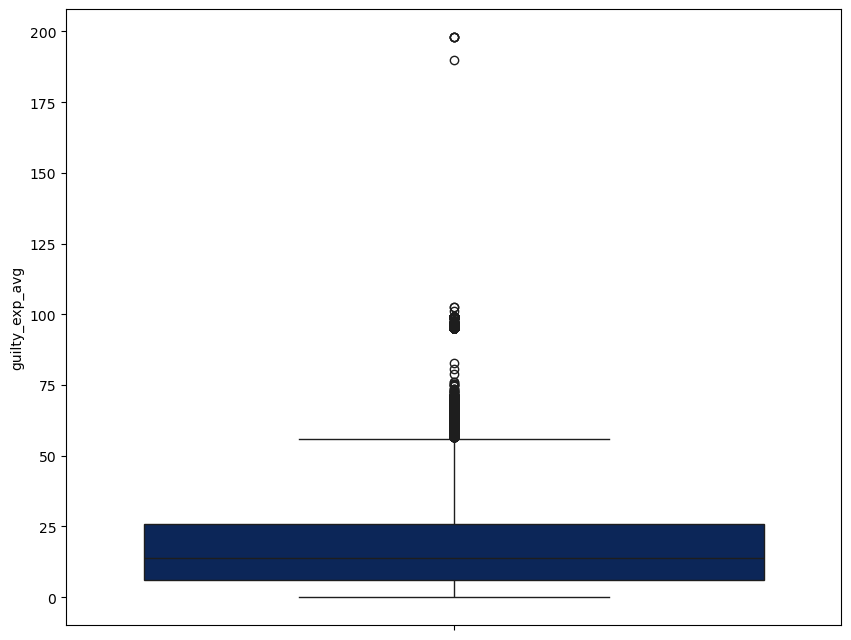

In [134]:
# 4й слайд
plt.figure(figsize=(10, 8))
sns.boxplot(df_merge['guilty_exp_avg'], color='#002264')

Q1 = df_merge['guilty_exp_avg'].quantile(0.25)
Q3 = df_merge['guilty_exp_avg'].quantile(0.75)
IQR = Q3 - Q1
df_merge = df_merge[(df_merge['guilty_exp_avg'] >= (Q1 - 1.5 * IQR)) & (df_merge['guilty_exp_avg'] <= (Q3 + 1.5 * IQR))]
df_merge['guilty_exp_avg'] = df_merge['guilty_exp_avg'].astype(int)

<Axes: xlabel='guilty_exp_avg', ylabel='Count'>

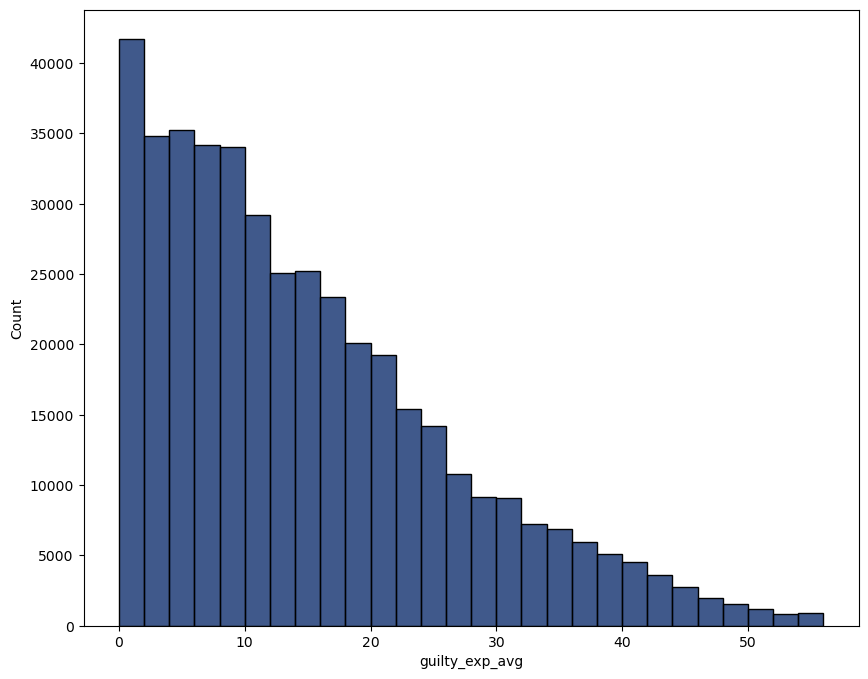

In [135]:
# 5й слайд
plt.figure(figsize=(10, 8))
sns.histplot(data=df_merge, x='guilty_exp_avg', bins=28, color='#002264')

<Axes: xlabel='n_VEHICLES', ylabel='Count'>

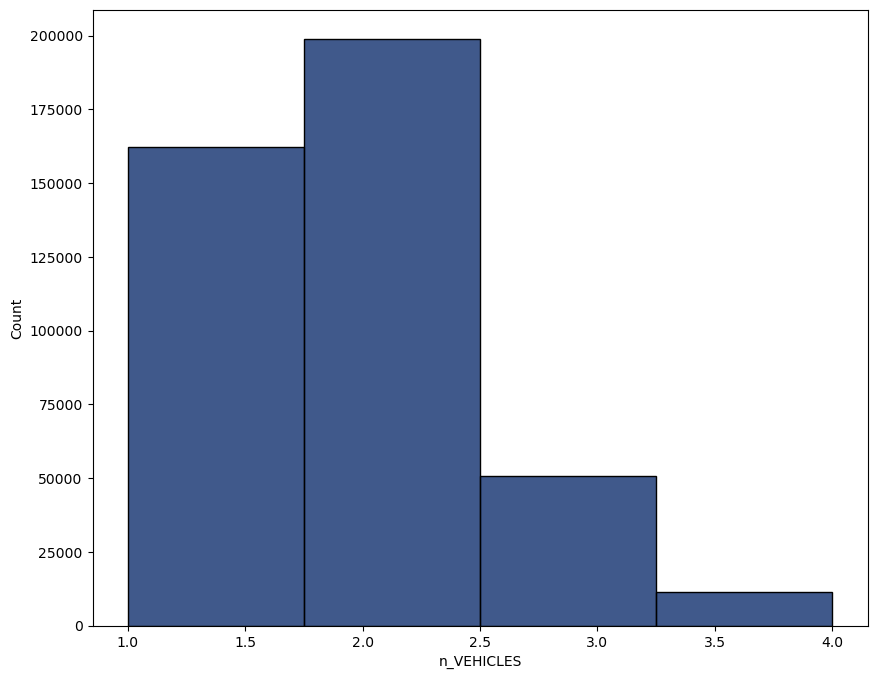

In [136]:
# 6й слайд
plt.figure(figsize=(10, 8))
sns.histplot(data=df_merge, x='n_VEHICLES', bins=4, color='#002264')

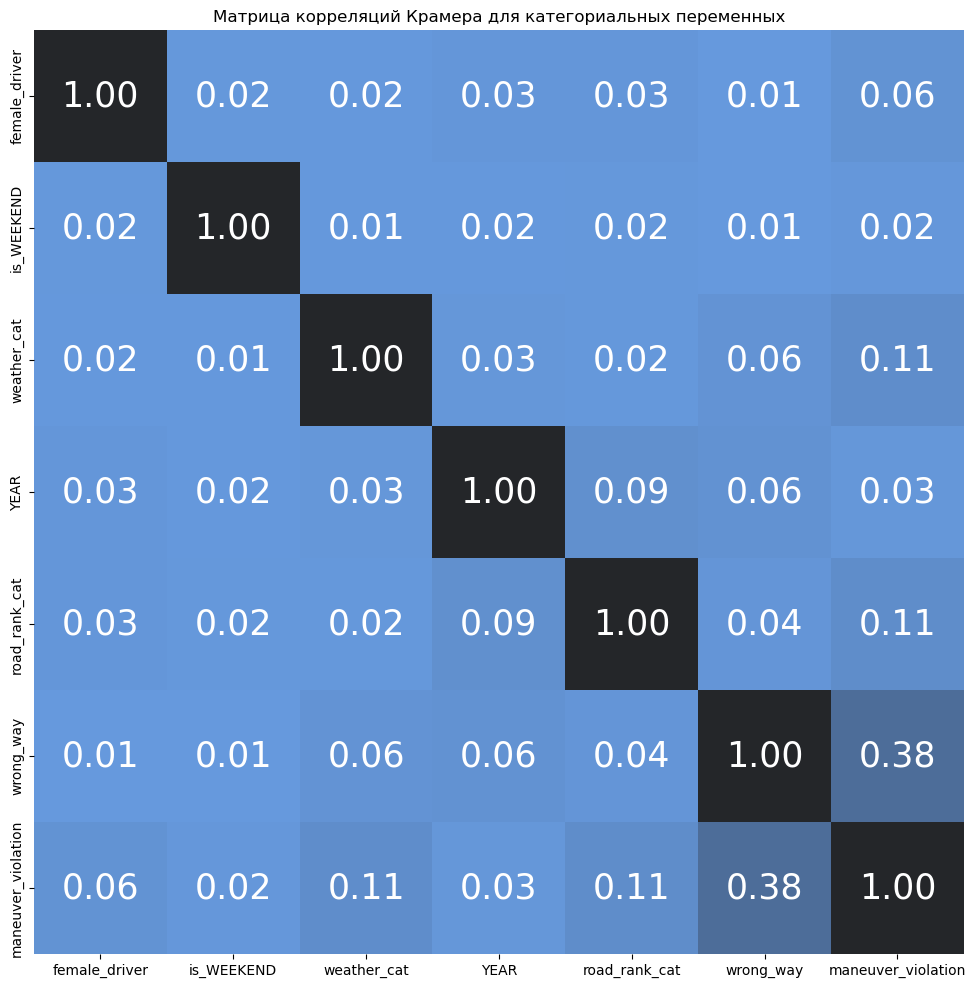

In [137]:
# 7й слайд
def cramers_v_correlation(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    if n == 0 or min_dim == 0:
        return 0.0
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    return cramers_v


df_agr = df_merge[['female_driver', 'is_WEEKEND', 'weather_cat',
                   'YEAR', 'road_rank_cat', 'wrong_way', 'maneuver_violation']]
col = df_agr.columns.tolist()
l = len(col)

matrix = np.zeros((l, l))

# Заполняем матрицу
for i in range(l):
    for j in range(l):
        if i == j:
            matrix[i, j] = 1.0  # Диагональ = 1
        else:
            matrix[i, j] = cramers_v_correlation(
                df_agr[col[i]], 
                df_agr[col[j]],
                )

# Создаем DataFrame с именами колонок
matrix_df = pd.DataFrame(
    matrix,
    index=col,
    columns=col
)

plt.figure(figsize=(12, 12))
sns.heatmap(matrix_df, annot=True, annot_kws={'rotation': 0, 'fontsize': '25'}, cbar=False, fmt='.2f', cmap=sns.dark_palette("#69d", reverse=True, as_cmap=True))
plt.title('Матрица корреляций Крамера для категориальных переменных')
plt.show()

In [138]:
# 8й слайд
print(pearsonr(df_merge.groupby('YEAR')['ID'].count().to_numpy(), [i for i in range(2015, 2025)]),
pearsonr(df_merge.groupby('YEAR')['guilty_exp_avg'].mean().to_numpy(), [i for i in range(2015, 2025)]),
pearsonr(df_merge.groupby('YEAR')['vehicle_age_min'].mean().to_numpy(), [i for i in range(2015, 2025)]),
pearsonr(df_merge.groupby('YEAR')['severity'].mean().to_numpy(), [i for i in range(2015, 2025)]), sep='\n')

PearsonRResult(statistic=np.float64(-0.8970409481541343), pvalue=np.float64(0.000433453964072582))
PearsonRResult(statistic=np.float64(0.997737088107084), pvalue=np.float64(1.1441127445054226e-10))
PearsonRResult(statistic=np.float64(0.9672339509851877), pvalue=np.float64(4.847244417669012e-06))
PearsonRResult(statistic=np.float64(-0.8715763743733014), pvalue=np.float64(0.0010162694206409387))


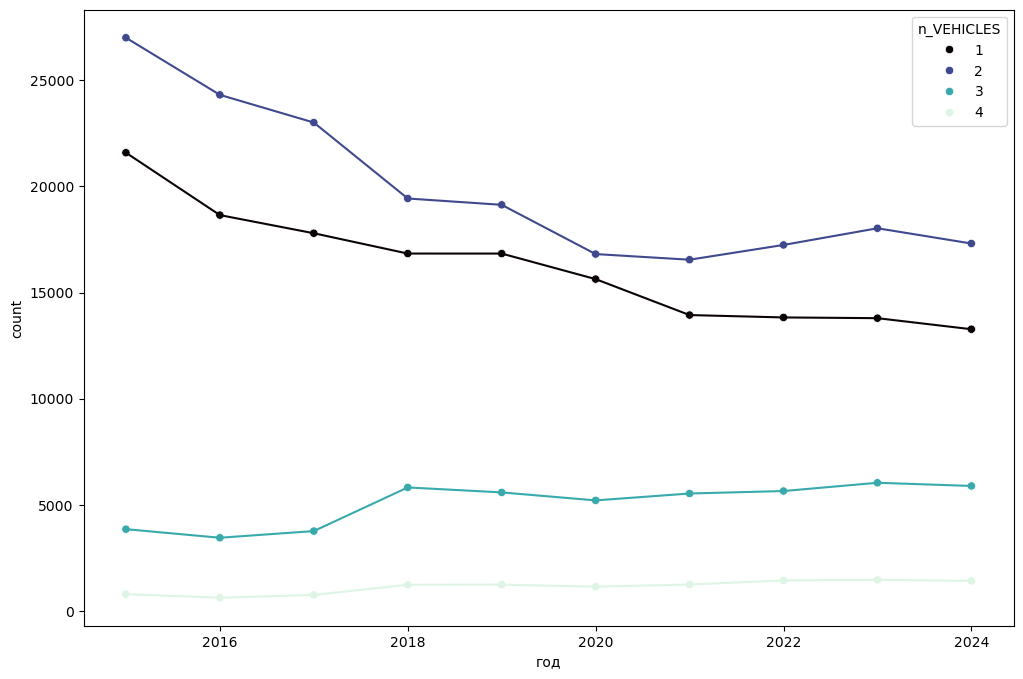

In [139]:
# 9й слайд
df_agr = df_merge[['YEAR', 'n_VEHICLES', 'ID']]
df_agr = df_agr.groupby(['YEAR', 'n_VEHICLES'], as_index = False).agg({'ID': 'count'})

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_agr, x='YEAR', y='ID', hue='n_VEHICLES', palette="mako")
sns.lineplot(data=df_agr, x='YEAR', y='ID', hue='n_VEHICLES', legend=False, palette="mako")
plt.ylabel('count')
plt.xlabel('год')
plt.show()

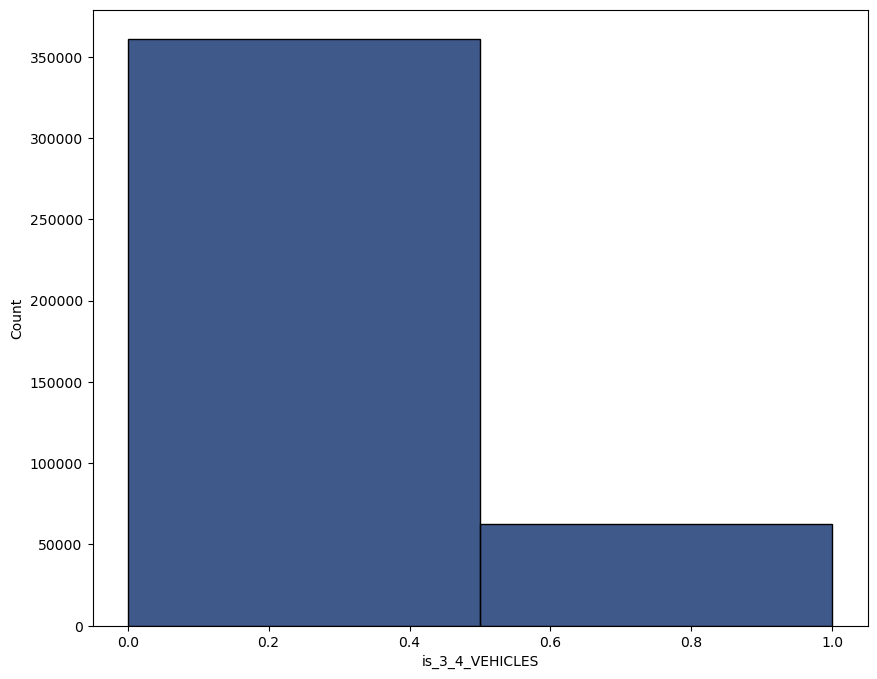

In [140]:
# 10й слайд
df_merge['n_VEHICLES'].value_counts()
# только 1, 2, 3 и 4
df_merge['is_3_4_VEHICLES'] = [1 if i >= 3 else 0 for i in df_merge['n_VEHICLES'].tolist()]
plt.figure(figsize=(10, 8))
sns.histplot(data=df_merge, x='is_3_4_VEHICLES', bins=2, color='#002264')
plt.show()

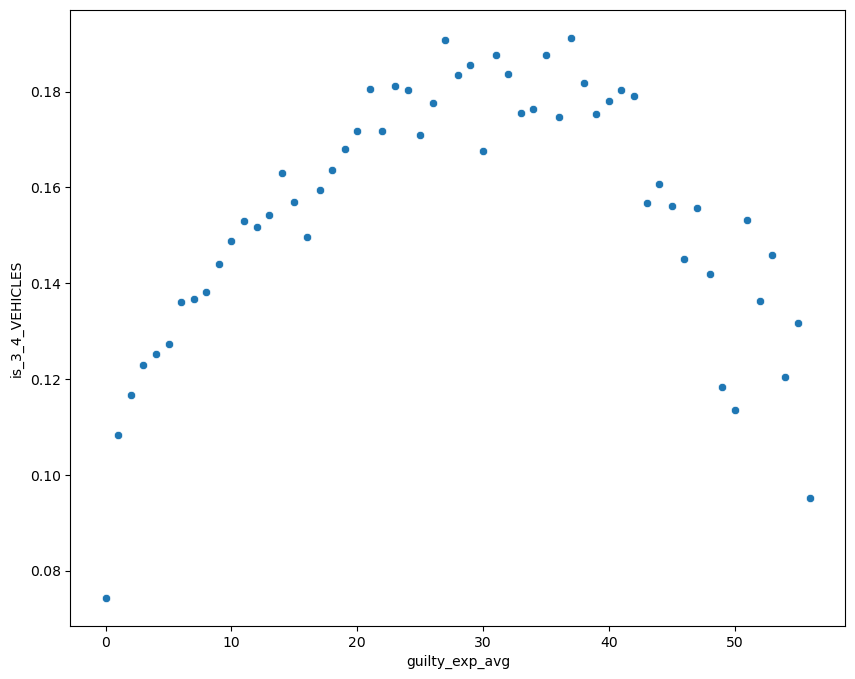

In [141]:
# 11й слайд
df_agr = df_merge[['guilty_exp_avg', 'is_3_4_VEHICLES']]
df_agr = df_agr.groupby('guilty_exp_avg', as_index = False).agg({'is_3_4_VEHICLES': 'mean'})
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_agr, x='guilty_exp_avg', y='is_3_4_VEHICLES')
plt.show()

In [142]:
df_merge['guilty_exp_avg_2'] = [i ** 2 for i in df_merge['guilty_exp_avg'].tolist()]

<Axes: xlabel='is_3_4_VEHICLES', ylabel='severity'>

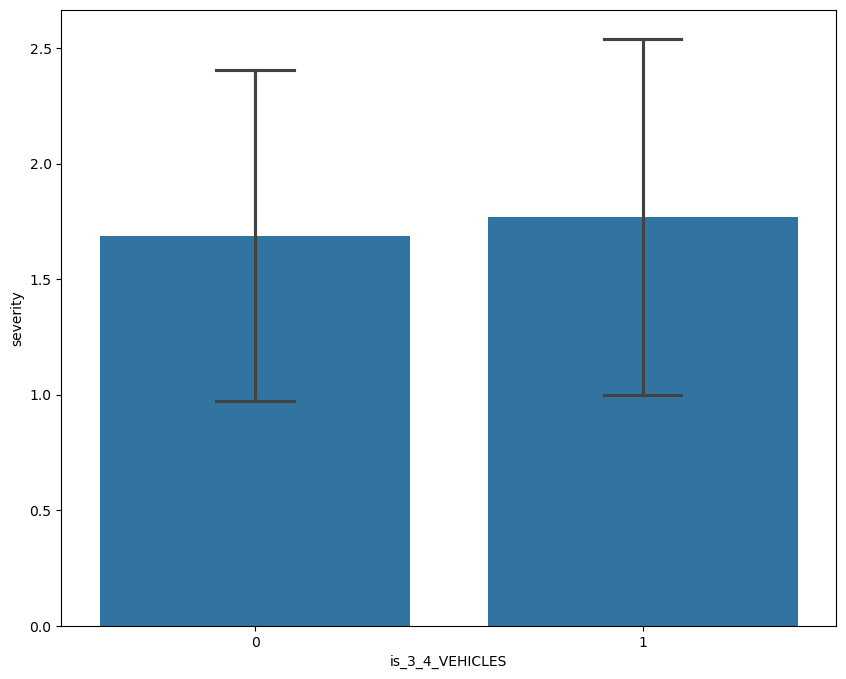

In [143]:
# 33й слайд
plt.figure(figsize=(10, 8))
sns.barplot(x='is_3_4_VEHICLES', y='severity', data=df_merge, errorbar="sd", capsize=.2)

<Axes: xlabel='YEAR', ylabel='ID'>

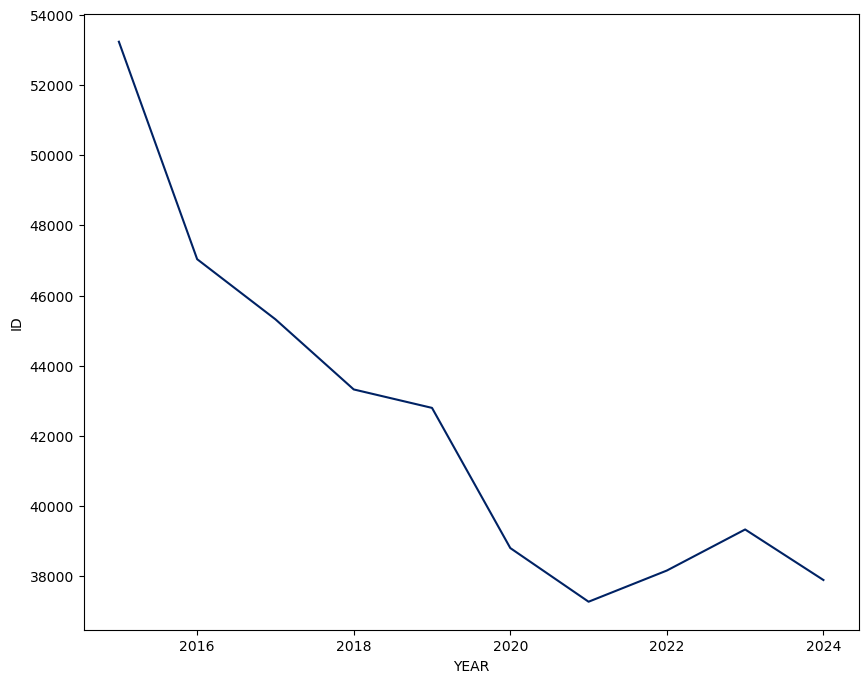

In [144]:
# 34й слайд
plt.figure(figsize=(10, 8))
sns.lineplot(df_merge.groupby('YEAR')['ID'].count(), color='#002264')

<Axes: xlabel='YEAR', ylabel='guilty_exp_avg'>

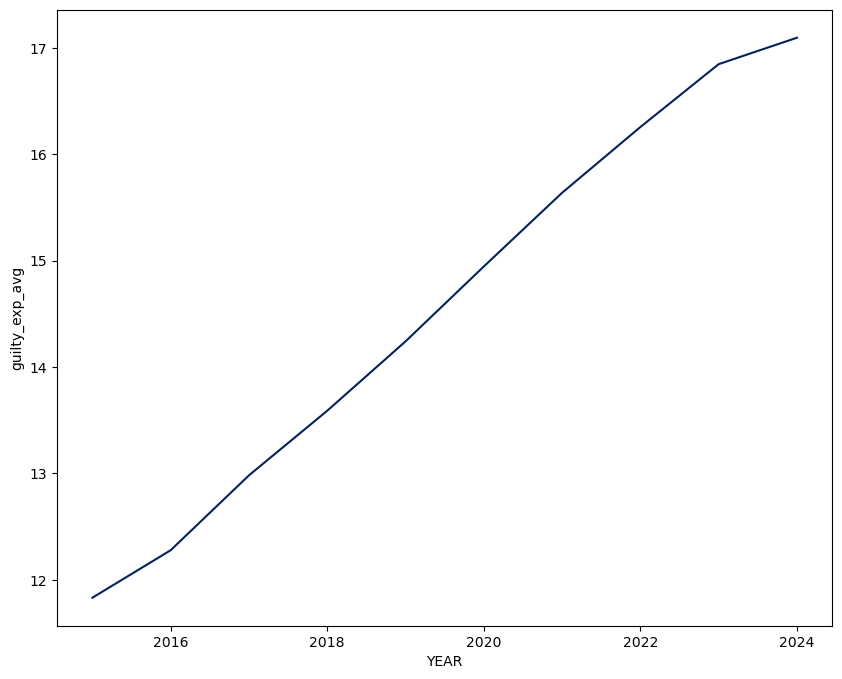

In [145]:
# 35й слайд
plt.figure(figsize=(10, 8))
sns.lineplot(df_merge.groupby('YEAR')['guilty_exp_avg'].mean(), color='#002264')

<Axes: xlabel='YEAR', ylabel='vehicle_age_min'>

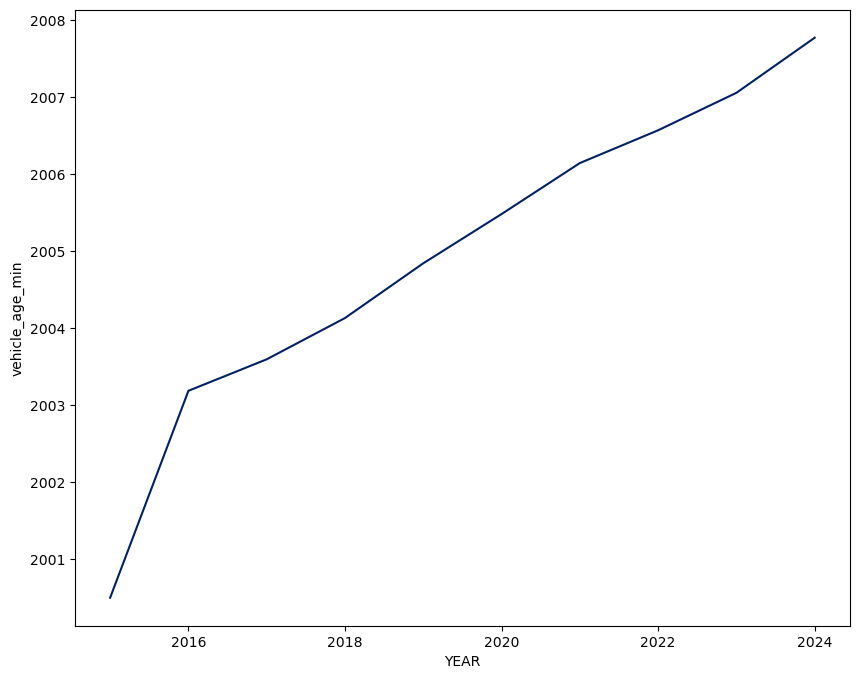

In [146]:
# 36й слайд
plt.figure(figsize=(10, 8))
sns.lineplot(df_merge.groupby('YEAR')['vehicle_age_min'].mean(), color='#002264')

<Axes: xlabel='YEAR', ylabel='severity'>

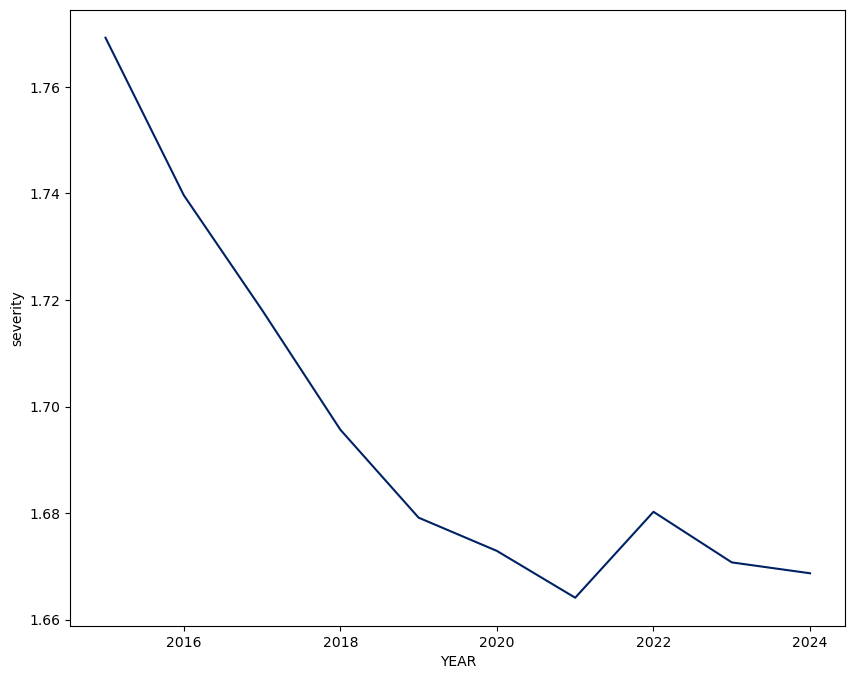

In [147]:
# 37й слайд
plt.figure(figsize=(10, 8))
sns.lineplot(df_merge.groupby('YEAR')['severity'].mean(), color='#002264')

<Axes: >

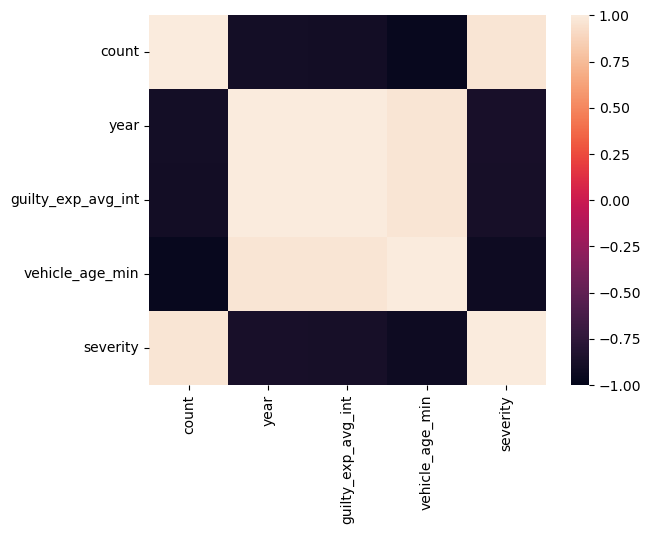

In [148]:
# 38й слайд
corr_data = pd.DataFrame({'count': df_merge.groupby('YEAR')['ID'].count().to_numpy(),\
              'year': [i for i in range(2015, 2025)],\
                'guilty_exp_avg_int': df_merge.groupby('YEAR')['guilty_exp_avg'].mean().to_numpy(),\
                    'vehicle_age_min': df_merge.groupby('YEAR')['vehicle_age_min'].mean().to_numpy(),\
                        'severity': df_merge.groupby('YEAR')['severity'].mean().to_numpy()})

sns.heatmap(corr_data.corr(), vmin=-1, vmax=1)

In [149]:
# 16й слайд
df_agr = df_merge[['guilty_exp_avg_2', 'guilty_exp_avg', 'is_3_4_VEHICLES']]
df_agr = sm.add_constant(df_agr)
m = sm.Logit(df_agr['is_3_4_VEHICLES'], df_agr.drop(columns = 'is_3_4_VEHICLES')).fit(maxiter = 500)
print(m.params)
# коэффы как на слайде, p-value маленькие
print(m.pvalues)

Optimization terminated successfully.
         Current function value: 0.414585
         Iterations 6
const              -2.176730
guilty_exp_avg_2   -0.000808
guilty_exp_avg      0.047108
dtype: float64
const                0.000000e+00
guilty_exp_avg_2    4.310011e-195
guilty_exp_avg       0.000000e+00
dtype: float64


In [150]:
df_merge = df_merge[df_merge['road_rank_cat'] != 'Не указано']
print(len(df_merge))

421512


In [151]:
REGION_TO_DISTRICT = {
  '24': 'Центральный федеральный округ',
  '28': 'Центральный федеральный округ',
  '29': 'Центральный федеральный округ',
  '32': 'Центральный федеральный округ',
  '33': 'Центральный федеральный округ',
  '34': 'Центральный федеральный округ',
  '38': 'Центральный федеральный округ',
  '42': 'Центральный федеральный округ',
  '46': 'Центральный федеральный округ',
  '54': 'Центральный федеральный округ',
  '61': 'Центральный федеральный округ',
  '66': 'Центральный федеральный округ',
  '68': 'Центральный федеральный округ',
  '71': 'Центральный федеральный округ',
  '78': 'Центральный федеральный округ',
  
  '1': 'Сибирский федеральный округ',
  '4': 'Сибирский федеральный округ',
  '14': 'Сибирский федеральный округ',
  '17': 'Сибирский федеральный округ',
  '19': 'Сибирский федеральный округ',
  '25': 'Сибирский федеральный округ',
  '50': 'Сибирский федеральный округ',
  '52': 'Сибирский федеральный округ',
  '69': 'Сибирский федеральный округ',
  '70': 'Сибирский федеральный округ',
  '84': 'Сибирский федеральный округ',
  '85': 'Сибирский федеральный округ',
  '93': 'Сибирский федеральный округ',
  
  '3': 'Южный федеральный округ',
  '8': 'Южный федеральный округ',
  '60': 'Южный федеральный округ',
  '67': 'Южный федеральный округ',
  '79': 'Южный федеральный округ',
  '35': 'Южный федеральный округ',


  '10': 'Северо-Западный федеральный округ',
  '11': 'Северо-Западный федеральный округ',
  '27': 'Северо-Западный федеральный округ',
  '40': 'Северо-Западный федеральный округ',
  '41': 'Северо-Западный федеральный округ',
  '47': 'Северо-Западный федеральный округ',
  '49': 'Северо-Западный федеральный округ',
  '58': 'Северо-Западный федеральный округ',
  '86': 'Северо-Западный федеральный округ',
  '87': 'Северо-Западный федеральный округ',
  '10011': 'Северо-Западный федеральный округ',
    
  '12': 'Приволжский федеральный округ',
  '18': 'Приволжский федеральный округ',
  '22': 'Приволжский федеральный округ',
  '36': 'Приволжский федеральный округ',
  '53': 'Приволжский федеральный округ',
  '56': 'Приволжский федеральный округ',
  '57': 'Приволжский федеральный округ',
  '63': 'Приволжский федеральный округ',
  '73': 'Приволжский федеральный округ',
  '80': 'Приволжский федеральный округ',
  '88': 'Приволжский федеральный округ',
  '89': 'Приволжский федеральный округ',
  '92': 'Приволжский федеральный округ',
  '94': 'Приволжский федеральный округ',
  '97': 'Приволжский федеральный округ',
  
  '37': 'Уральский федеральный округ',
  '45': 'Уральский федеральный округ',
  '65': 'Уральский федеральный округ',
  '75': 'Уральский федеральный округ',
  '71100': 'Уральский федеральный округ',
  '71140': 'Уральский федеральный округ',
  
  '7': 'Северо-Кавказский федеральный округ',
  '15': 'Северо-Кавказский федеральный округ',
  '20': 'Северо-Кавказский федеральный округ',
  '26': 'Северо-Кавказский федеральный округ',
  '82': 'Северо-Кавказский федеральный округ',
  '83': 'Северо-Кавказский федеральный округ',
  '90': 'Северо-Кавказский федеральный округ',
  '91': 'Северо-Кавказский федеральный округ',
  
  '5': 'ДФО',
  '30': 'ДФО',
  '44': 'ДФО',
  '64': 'ДФО',
  '76': 'ДФО',
  '77': 'ДФО',
  '81': 'ДФО',
  '98': 'ДФО',
  '99': 'ДФО'
}

In [152]:
ALTERNATIVE_TO_MAIN = {
    '71100': '86',  # Ханты-Мансийский АО (альтернативный → основной)

    # Преобразование кодов с ведущими нулями в коды без нулей
    '01': '1',  # Адыгея
    '02': '2',  # Башкортостан
    '03': '3',  # Бурятия
    '04': '4',  # Алтай
    '05': '5',  # Дагестан
    '06': '6',  # Ингушетия
    '07': '7',  # Кабардино-Балкария
    '08': '8',  # Калмыкия
    '09': '9',  # Карачаево-Черкесия
}
# Словарь названий округов для красивого вывода
DISTRICT_NAMES = {
    'ЦФО': 'Центральный',
    'СЗФО': 'Северо-Западный',
    'ЮФО': 'Южный',
    'СКФО': 'Северо-Кавказский',
    'ПФО': 'Приволжский',
    'УФО': 'Уральский',
    'СФО': 'Сибирский',
    'ДФО': 'Дальневосточный'
}

# Обратный словарь для получения кода по названию
DISTRICT_CODES = {v: k for k, v in DISTRICT_NAMES.items()}

"""Подготовка данных: присвоение федеральных округов"""
print("=" * 60)
print("ПОДГОТОВКА ДАННЫХ И ПРИСВОЕНИЕ ФЕДЕРАЛЬНЫХ ОКРУГОВ")
print("=" * 60)

df_prepared = df_merge.copy()
# Преобразуем REGION в строку
df_prepared['REGION'] = df_prepared['REGION'].astype(str).str.strip()
print(f"Исходное количество записей: {len(df_prepared):,}")
print(f"Уникальных кодов регионов: {df_prepared['REGION'].nunique()}")

# Показываем топ-10 самых частых кодов
region_counts = df_prepared['REGION'].value_counts().head(10)
print("\nТоп-10 самых частых кодов регионов:")
for code, count in region_counts.items():
    print(f"  {code}: {count:,} записей ({count / len(df_prepared) * 100:.1f}%)")

# 1. Преобразование альтернативных кодов
original_codes = df_prepared['REGION'].unique()
df_prepared['REGION'] = df_prepared['REGION'].replace(ALTERNATIVE_TO_MAIN)

converted = [code for code in original_codes if code in ALTERNATIVE_TO_MAIN]
if converted:
    print(f"\nПреобразовано альтернативных кодов: {len(converted)}")
    for code in converted:
        print(f"  {code} → {ALTERNATIVE_TO_MAIN[code]} (Ханты-Мансийский АО)")

# 2. Присвоение округов
df_prepared['FEDERAL_DISTRICT'] = df_prepared['REGION'].map(REGION_TO_DISTRICT)

# 3. Удаление некорректных записей
mask_delete = df_prepared['FEDERAL_DISTRICT'] == 'УДАЛИТЬ'
delete_count = mask_delete.sum()

if delete_count > 0:
    print(f"\nУдалено записей с некорректными кодами: {delete_count:,}")
    deleted_codes = df_prepared.loc[mask_delete, 'REGION'].unique()
    for code in deleted_codes:
        count = (df_prepared['REGION'] == code).sum()
        print(f"  Код {code}: {count:,} записей")

df_prepared = df_prepared[~mask_delete].copy()

# 4. Статистика по присвоенным округам
district_stats = df_prepared['FEDERAL_DISTRICT'].value_counts()
print(f"\nРаспределение по федеральным округам:")
print("-" * 50)
total = len(df_prepared)

for district, count in district_stats.items():
    if pd.notna(district):
        percentage = count / total * 100
        district_name = DISTRICT_NAMES.get(district, district)
        print(f"{district_name:<25} [{district:<4}] {count:>8,} ({percentage:>5.1f}%)")

print(f"\nИтоговое количество записей для анализа: {len(df_prepared):,}")

ПОДГОТОВКА ДАННЫХ И ПРИСВОЕНИЕ ФЕДЕРАЛЬНЫХ ОКРУГОВ
Исходное количество записей: 421,512
Уникальных кодов регионов: 85

Топ-10 самых частых кодов регионов:
  3: 25,351 записей (6.0%)
  41: 15,131 записей (3.6%)
  22: 12,577 записей (3.0%)
  46: 11,471 записей (2.7%)
  45: 11,236 записей (2.7%)
  7: 10,671 записей (2.5%)
  92: 10,393 записей (2.5%)
  80: 10,255 записей (2.4%)
  60: 10,060 записей (2.4%)
  36: 8,965 записей (2.1%)

Преобразовано альтернативных кодов: 1
  71100 → 86 (Ханты-Мансийский АО)

Распределение по федеральным округам:
--------------------------------------------------
Приволжский федеральный округ [Приволжский федеральный округ]   92,208 ( 21.9%)
Центральный федеральный округ [Центральный федеральный округ]   77,011 ( 18.3%)
Сибирский федеральный округ [Сибирский федеральный округ]   60,933 ( 14.5%)
Южный федеральный округ   [Южный федеральный округ]   48,825 ( 11.6%)
Северо-Западный федеральный округ [Северо-Западный федеральный округ]   47,780 ( 11.3%)
Северо-Кав

In [153]:
data_for_regressions = df_merge[['guilty_exp_avg','guilty_exp_avg_2','YEAR', 'is_WEEKEND',
                                 'female_driver', 'adj_objects_interpretable', 'is_3_4_VEHICLES',
                                 'is_NIGHT', 'road_rank_cat', 'maneuver_violation', 'wrong_way']]

In [154]:
# Выделяем категориальные переменные для кодирования
categorical_cols = ['adj_objects_interpretable', 'road_rank_cat']
categorical_data = data_for_regressions[categorical_cols]

# Создаем и применяем OneHotEncoder (создаем все колонки)
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(categorical_data)

# Создаем имена для ВСЕХ новых колонок
encoded_columns = []
for col, categories in zip(categorical_cols, encoder.categories_):
    encoded_columns.extend([f'{col}_{cat}' for cat in categories])  # Используем ВСЕ категории

encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns, index=data_for_regressions.index)

# Удаляем исходные категориальные колонки и добавляем закодированные
data_encoded = data_for_regressions.drop(columns=categorical_cols)
data_encoded = pd.concat([data_encoded, encoded_df], axis=1)

# Удаляем конкретные dummy-колонки
data_encoded = data_encoded.drop(
    columns=['road_rank_cat_Региональная или межмуниципальная', 'adj_objects_interpretable_no_obj']
)

In [155]:
X = data_encoded[['is_3_4_VEHICLES', 'guilty_exp_avg_2', 'guilty_exp_avg']].drop(columns=['is_3_4_VEHICLES']).astype(float)
y = data_encoded['is_3_4_VEHICLES']

X = sm.add_constant(X)

logit_model = sm.Logit(y, X)
result = logit_model.fit()

display(result.summary())

Optimization terminated successfully.
         Current function value: 0.415165
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        is_3_4_VEHICLES   No. Observations:               421512
Model:                          Logit   Df Residuals:                   421509
Method:                           MLE   Df Model:                            2
Date:                Tue, 16 Dec 2025   Pseudo R-squ.:                0.006777
Time:                        08:05:29   Log-Likelihood:            -1.7500e+05
converged:                       True   LL-Null:                   -1.7619e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.1736      0.010   -213.577      0.000      -2.194      -2.154
guilty_exp_avg_2    -0.0008   2.71e-05    -29.731      0.000      -0.001      -0.001
guilty_exp_avg       0.0470      0.001     40.391      0.000       0.045       0.049
====================================================================================
"""

In [156]:
from sklearn.model_selection import train_test_split
#контрольные переменные
# Выделяем предикторы и таргет
X = data_encoded.drop(columns=['is_3_4_VEHICLES']).astype(float)
y = data_encoded['is_3_4_VEHICLES']

X = sm.add_constant(X)

logit_model = sm.Logit(y, X)
result = logit_model.fit()

display(result.summary())

Optimization terminated successfully.
         Current function value: 0.380140
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        is_3_4_VEHICLES   No. Observations:               421512
Model:                          Logit   Df Residuals:                   421495
Method:                           MLE   Df Model:                           16
Date:                Tue, 16 Dec 2025   Pseudo R-squ.:                 0.09057
Time:                        08:05:33   Log-Likelihood:            -1.6023e+05
converged:                       True   LL-Null:                   -1.7619e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                     -205.1722      3.229    -63.531      0.000    -211.502    -198.843
guilty_exp_avg                               0.0368      0.001     30.258      0.000       0.034       0.039
guilty_exp_avg_2                            -0.0007   2.81e-05    -24.917      0.000      -0.001      -0.001
YEAR                                         0.1000      0.002     62.563      0.000       0.097       0.103
is_WEEKEND                                  -0.1154      0.010    -11.702      0.000      -0.135      -0.096
female_driver                                0.1780      0.011     15.960      0.000       0.156       0.200
is_NIGHT                                    -0.0785      0.013     -6.039      0.000      -0.104      -0.053
maneuver_violation                           1.1673      0.011    108.158      0.000       1.146       1.188
wrong_way                                    0.6716      0.011     60.594      0.000       0.650       0.693
adj_objects_interpretable_LIVING_OBJ        -0.2374      0.017    -14.304      0.000      -0.270      -0.205
adj_objects_interpretable_ROAD_INFRSTRCT     0.0779      0.014      5.697      0.000       0.051       0.105
adj_objects_interpretable_SOCIAL_OBJ         0.0431      0.019      2.280      0.023       0.006       0.080
adj_objects_interpretable_TRANSPORT_OBJ     -0.0701      0.018     -3.845      0.000      -0.106      -0.034
road_rank_cat_Другие места                  -0.5997      0.148     -4.045      0.000      -0.890      -0.309
road_rank_cat_Местного значения             -0.4117      0.026    -16.030      0.000      -0.462      -0.361
road_rank_cat_Федеральная                    0.8176      0.009     87.258      0.000       0.799       0.836
road_rank_cat_Частная                        0.4083      0.094      4.358      0.000       0.225       0.592
============================================================================================================
"""

In [157]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(data, features, threshold=10, add_intercept=True):
    X = data[features].copy()

    if add_intercept:
        X = add_constant(X)
        vif_features = X.columns
    else:
        vif_features = X.columns
    vif_data = pd.DataFrame()
    vif_data["feature"] = vif_features
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                      for i in range(X.shape[1])]
    vif_data = vif_data.sort_values("VIF", ascending=False)
    return vif_data

print("=" * 80)
print("АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ (VIF) ДЛЯ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")
print("=" * 80)



r = [col for col in data_encoded.columns]
r.remove('is_3_4_VEHICLES')
available_predictors = [p for p in r]
print("\nРасчет VIF для предикторов...")
vif_results = calculate_vif(data_encoded, available_predictors, threshold=5, add_intercept=True)
print("\nРЕЗУЛЬТАТЫ АНАЛИЗА VIF:")
print("=" * 60)
print(vif_results.to_string(index=True))
print("=" * 60)

АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ (VIF) ДЛЯ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

Расчет VIF для предикторов...

РЕЗУЛЬТАТЫ АНАЛИЗА VIF:
                                     feature            VIF
0                                      const  500758.274260
1                             guilty_exp_avg       9.135052
2                           guilty_exp_avg_2       9.008731
7                         maneuver_violation       1.233665
8                                  wrong_way       1.184327
15                 road_rank_cat_Федеральная       1.071710
10  adj_objects_interpretable_ROAD_INFRSTRCT       1.057680
14           road_rank_cat_Местного значения       1.054331
9       adj_objects_interpretable_LIVING_OBJ       1.052290
5                              female_driver       1.048315
12   adj_objects_interpretable_TRANSPORT_OBJ       1.042229
3                                       YEAR       1.038167
6                                   is_NIGHT       1.037313
11      adj_objects_interpretable_SOCIAL_O

In [158]:
X = data_encoded.drop(columns=['is_3_4_VEHICLES']).astype(float)
y = data_encoded['is_3_4_VEHICLES']
X = sm.add_constant(X)

logit_model = sm.Logit(y, X)
robust_types = ['HC0', 'HC1', 'HC2', 'HC3']
results_dict = {}

for rtype in robust_types:
    results_dict[rtype] = logit_model.fit(cov_type=rtype, disp=False, maxiter=200)

comparison_data = []
base_result = results_dict.get('HC3')

if base_result is not None:
    for param in base_result.params.index:
        row = {'Параметр': param}
        
        for rtype in robust_types:
            result = results_dict.get(rtype)
            if result is not None and param in result.params.index:
                row[f'{rtype}_coef'] = result.params[param]
                row[f'{rtype}_se'] = result.bse[param]
                row[f'{rtype}_p'] = result.pvalues[param]
            else:
                row[f'{rtype}_coef'] = np.nan
                row[f'{rtype}_se'] = np.nan
                row[f'{rtype}_p'] = np.nan
        
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

display_df = pd.DataFrame()
display_df['Параметр'] = comparison_df['Параметр']

for rtype in robust_types:
    display_df[f'{rtype} (β)'] = comparison_df[f'{rtype}_coef'].apply(lambda x: f'{x:.4f}')
    display_df[f'{rtype} (SE)'] = comparison_df[f'{rtype}_se'].apply(lambda x: f'{x:.4f}')
    display_df[f'{rtype} (p)'] = comparison_df[f'{rtype}_p'].apply(lambda x: f'{x:.4f}')

print("Сравнение коэффициентов для разных типов робастных ошибок:")
display(display_df)

Сравнение коэффициентов для разных типов робастных ошибок:


,Параметр,HC0 (β),HC0 (SE),HC0 (p),HC1 (β),HC1 (SE),HC1 (p),HC2 (β),HC2 (SE),HC2 (p),HC3 (β),HC3 (SE),HC3 (p)
0,const,-205.1722,3.1605,0.0000,-205.1722,3.1605,0.0000,-205.1722,3.1605,0.0000,-205.1722,3.1605,0.0000
1,guilty_exp_avg,0.0368,0.0012,0.0000,0.0368,0.0012,0.0000,0.0368,0.0012,0.0000,0.0368,0.0012,0.0000
2,guilty_exp_avg_2,-0.0007,0.0000,0.0000,-0.0007,0.0000,0.0000,-0.0007,0.0000,0.0000,-0.0007,0.0000,0.0000
3,YEAR,0.1000,0.0016,0.0000,0.1000,0.0016,0.0000,0.1000,0.0016,0.0000,0.1000,0.0016,0.0000
4,is_WEEKEND,-0.1154,0.0099,0.0000,-0.1154,0.0099,0.0000,-0.1154,0.0099,0.0000,-0.1154,0.0099,0.0000
5,female_driver,0.1780,0.0114,0.0000,0.1780,0.0114,0.0000,0.1780,0.0114,0.0000,0.1780,0.0114,0.0000
6,is_NIGHT,-0.0785,0.0129,0.0000,-0.0785,0.0129,0.0000,-0.0785,0.0129,0.0000,-0.0785,0.0129,0.0000
7,maneuver_violation,1.1673,0.0106,0.0000,1.1673,0.0106,0.0000,1.1673,0.0106,0.0000,1.1673,0.0106,0.0000
8,wrong_way,0.6716,0.0108,0.0000,0.6716,0.0108,0.0000,0.6716,0.0108,0.0000,0.6716,0.0108,0.0000
9,adj_objects_interpretable_LIVING_OBJ,-0.2374,0.0167,0.0000,-0.2374,0.0167,0.0000,-0.2374,0.0167,0.0000,-0.2374,0.0167,0.0000


Округ nan: ошибка при обучении модели - zero-size array to reduction operation maximum which has no identity

СВОДНАЯ ТАБЛИЦА: КОЭФФИЦИЕНТЫ И ВЕРШИНЫ ПАРАБОЛ
                           district beta1 (guilty_exp_avg) beta2 (guilty_exp_avg_2) vertex_x vertex_prob
                         ВСЕ ОКРУГА                 0.0368                  -0.0007    26.30        0.14
        Сибирский федеральный округ                 0.0391                  -0.0007    27.93        0.14
            Южный федеральный округ                 0.0401                  -0.0008    24.84        0.15
                                ДФО                 0.0383                  -0.0008    25.31        0.08
Северо-Кавказский федеральный округ                 0.0254                  -0.0004    29.20        0.13
  Северо-Западный федеральный округ                 0.0405                  -0.0008    25.89        0.13
      Приволжский федеральный округ                 0.0372                  -0.0007    26.19        0.14
  

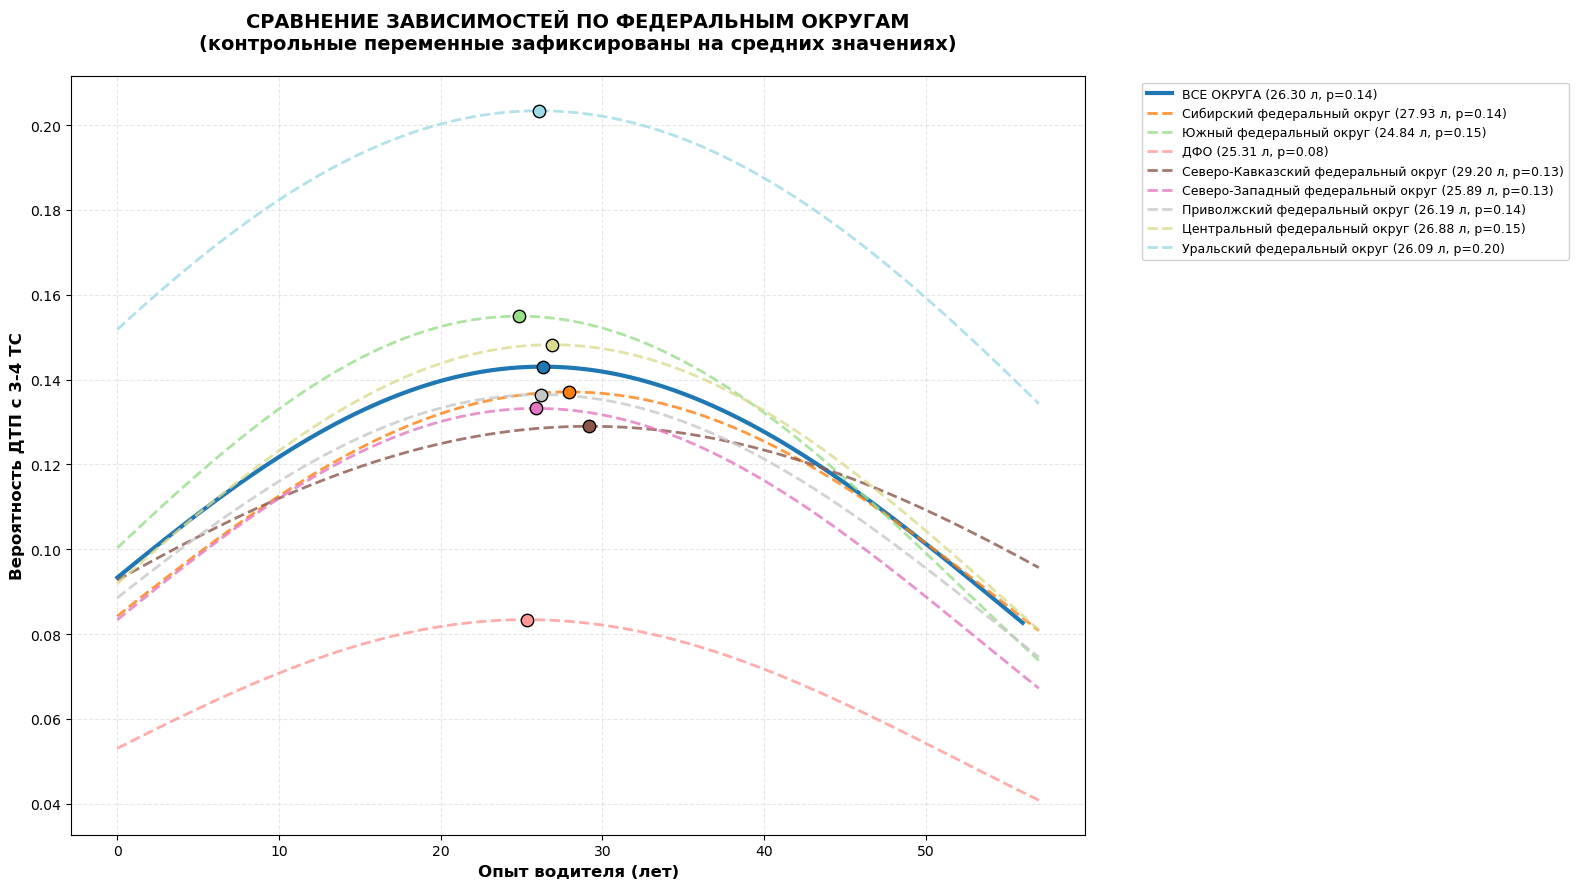

In [159]:
warnings.filterwarnings('ignore')

predictors = [col for col in data_encoded.columns 
              if col not in ['is_3_4_VEHICLES', 'FEDERAL_DISTRICT']]
required_vars = ['guilty_exp_avg', 'guilty_exp_avg_2']
data_encoded['FEDERAL_DISTRICT'] = df_prepared['FEDERAL_DISTRICT'].copy()
missing_vars = [var for var in required_vars if var not in predictors]
if missing_vars:
    raise ValueError(f"Отсутствуют обязательные переменные: {missing_vars}")

control_vars = [col for col in predictors if col not in required_vars]
districts = data_encoded['FEDERAL_DISTRICT'].unique()

results_list = []
X_all = data_encoded[predictors].astype(float)
X_all = sm.add_constant(X_all)
y_all = data_encoded['is_3_4_VEHICLES']

model_all = sm.Logit(y_all, X_all).fit(disp=False, maxiter=200)
mean_control_all = data_encoded[control_vars].mean()
x_range_all = np.linspace(
    data_encoded['guilty_exp_avg'].min(), 
    data_encoded['guilty_exp_avg'].max(), 
    100
)
viz_df_all = pd.DataFrame({
    'guilty_exp_avg': x_range_all,
    'guilty_exp_avg_2': x_range_all**2
})

for col in control_vars:
    if col in data_encoded.columns:
        viz_df_all[col] = mean_control_all[col]

viz_df_all = sm.add_constant(viz_df_all, has_constant='add')
aligned_data = pd.DataFrame(index=viz_df_all.index)
for col in model_all.params.index:
    aligned_data[col] = viz_df_all[col]
viz_df_all = aligned_data
log_odds_all = viz_df_all.dot(model_all.params)
probs_all = 1 / (1 + np.exp(-log_odds_all))
coef_all = model_all.params
vertex_x_all = -coef_all['guilty_exp_avg'] / (2 * coef_all['guilty_exp_avg_2'])
vertex_idx = np.argmin(np.abs(viz_df_all['guilty_exp_avg'] - vertex_x_all))
vertex_prob_all = probs_all.iloc[vertex_idx]

results_list.append({
    'district': 'ВСЕ ОКРУГА',
    'beta1 (guilty_exp_avg)': coef_all.get('guilty_exp_avg', np.nan),
    'beta2 (guilty_exp_avg_2)': coef_all.get('guilty_exp_avg_2', np.nan),
    'p_value_guilty_exp_avg_2': model_all.pvalues.get('guilty_exp_avg_2', np.nan),
    'vertex_x': vertex_x_all,
    'vertex_prob': vertex_prob_all,
    'n_obs': len(y_all)
})

for i, district in enumerate(districts):
    district_data = data_encoded[data_encoded['FEDERAL_DISTRICT'] == district]
    X_district = district_data[predictors].astype(float)
    X_district = sm.add_constant(X_district)
    y_district = district_data['is_3_4_VEHICLES']
    
    try:
        model_district = sm.Logit(y_district, X_district).fit(disp=False, maxiter=200)
    except Exception as e:
        print(f"Округ {district}: ошибка при обучении модели - {str(e)}")
        continue
    
    mean_control_district = district_data[control_vars].mean()
    x_min = max(0, district_data['guilty_exp_avg'].min() - 1)
    x_max = district_data['guilty_exp_avg'].max() + 1
    x_range = np.linspace(x_min, x_max, 100)
    
    viz_df = pd.DataFrame({
        'guilty_exp_avg': x_range,
        'guilty_exp_avg_2': x_range**2
    })
    
    for col in control_vars:
        if col in district_data.columns:
            viz_df[col] = mean_control_district[col]
    
    viz_df = sm.add_constant(viz_df, has_constant='add')
    aligned_viz = pd.DataFrame(index=viz_df.index)
    for col in model_district.params.index:
        if col in viz_df.columns:
            aligned_viz[col] = viz_df[col]
        else:
            aligned_viz[col] = 0
    viz_df = aligned_viz
    
    log_odds = viz_df.dot(model_district.params)
    probs = 1 / (1 + np.exp(-log_odds))
    coef_district = model_district.params
    
    if 'guilty_exp_avg' in coef_district.index and 'guilty_exp_avg_2' in coef_district.index:
        vertex_x = -coef_district['guilty_exp_avg'] / (2 * coef_district['guilty_exp_avg_2'])
        vertex_idx = np.argmin(np.abs(viz_df['guilty_exp_avg'] - vertex_x))
        vertex_prob = probs.iloc[vertex_idx]
    else:
        vertex_x = np.nan
        vertex_prob = np.nan
        print(f"Предупреждение: не удалось рассчитать вершину для {district}")
    
    results_list.append({
        'district': district,
        'beta1 (guilty_exp_avg)': coef_district.get('guilty_exp_avg', np.nan),
        'beta2 (guilty_exp_avg_2)': coef_district.get('guilty_exp_avg_2', np.nan),
        'p_value_guilty_exp_avg_2': model_district.pvalues.get('guilty_exp_avg_2', np.nan),
        'vertex_x': vertex_x,
        'vertex_prob': vertex_prob,
        'n_obs': len(y_district)
    })

results_df = pd.DataFrame(results_list)
summary_table = results_df[['district', 'beta1 (guilty_exp_avg)', 
                           'beta2 (guilty_exp_avg_2)', 'vertex_x', 'vertex_prob']].copy()
summary_table['beta1 (guilty_exp_avg)'] = summary_table['beta1 (guilty_exp_avg)'].map('{:.4f}'.format)
summary_table['beta2 (guilty_exp_avg_2)'] = summary_table['beta2 (guilty_exp_avg_2)'].map('{:.4f}'.format)
summary_table['vertex_x'] = summary_table['vertex_x'].map('{:.2f}'.format)
summary_table['vertex_prob'] = summary_table['vertex_prob'].map('{:.2f}'.format)

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА: КОЭФФИЦИЕНТЫ И ВЕРШИНЫ ПАРАБОЛ")
print("="*80)
print(summary_table.to_string(index=False))

plt.figure(figsize=(16, 9))
colors = plt.cm.tab20(np.linspace(0, 1, len(results_df)))

for idx, row in results_df.iterrows():
    district = row['district']
    
    if district == 'ВСЕ ОКРУГА':
        model = model_all
        mean_control = data_encoded[control_vars].mean()
        x_min = data_encoded['guilty_exp_avg'].min()
        x_max = data_encoded['guilty_exp_avg'].max()
    else:
        district_data = data_encoded[data_encoded['FEDERAL_DISTRICT'] == district]
        X_district = district_data[predictors].astype(float)
        X_district = sm.add_constant(X_district)
        y_district = district_data['is_3_4_VEHICLES']
        model = sm.Logit(y_district, X_district).fit(disp=False, maxiter=200)
        mean_control = district_data[control_vars].mean()
        x_min = max(0, district_data['guilty_exp_avg'].min() - 1)
        x_max = district_data['guilty_exp_avg'].max() + 1
    
    x_range = np.linspace(x_min, x_max, 100)
    viz_df = pd.DataFrame({
        'guilty_exp_avg': x_range,
        'guilty_exp_avg_2': x_range**2
    })
    
    for col in control_vars:
        if col in data_encoded.columns:
            viz_df[col] = mean_control[col]
    
    viz_df = sm.add_constant(viz_df, has_constant='add')
    aligned_viz = pd.DataFrame(index=viz_df.index)
    for col in model.params.index:
        if col in viz_df.columns:
            aligned_viz[col] = viz_df[col]
        else:
            aligned_viz[col] = 0
    viz_df = aligned_viz
    
    log_odds = viz_df.dot(model.params)
    probs = 1 / (1 + np.exp(-log_odds))
    
    linestyle = '-' if district == 'ВСЕ ОКРУГА' else '--'
    linewidth = 3 if district == 'ВСЕ ОКРУГА' else 2
    alpha = 1.0 if district == 'ВСЕ ОКРУГА' else 0.8
    
    if not np.isnan(row['vertex_x']) and not np.isnan(row['vertex_prob']):
        vertex_x_str = f"{row['vertex_x']:.2f}"
        vertex_prob_str = f"{row['vertex_prob']:.2f}"
        label = f"{district} ({vertex_x_str} л, p={vertex_prob_str})"
    else:
        label = f"{district}"
    
    plt.plot(x_range, probs, linewidth=linewidth, linestyle=linestyle,
             alpha=alpha, color=colors[idx], label=label)
    
    if not np.isnan(row['vertex_x']) and not np.isnan(row['vertex_prob']):
        plt.scatter([row['vertex_x']], [row['vertex_prob']], 
                    color=colors[idx], s=80, edgecolor='black', zorder=5)

plt.xlabel('Опыт водителя (лет)', fontsize=12, fontweight='bold')
plt.ylabel('Вероятность ДТП с 3-4 ТС', fontsize=12, fontweight='bold')
plt.title('СРАВНЕНИЕ ЗАВИСИМОСТЕЙ ПО ФЕДЕРАЛЬНЫМ ОКРУГАМ\n(контрольные переменные зафиксированы на средних значениях)', 
          fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

bootstrap итерации: 100%|██████████████████████████████████████████████████████████| 1000/1000 [01:22<00:00, 12.08it/s]


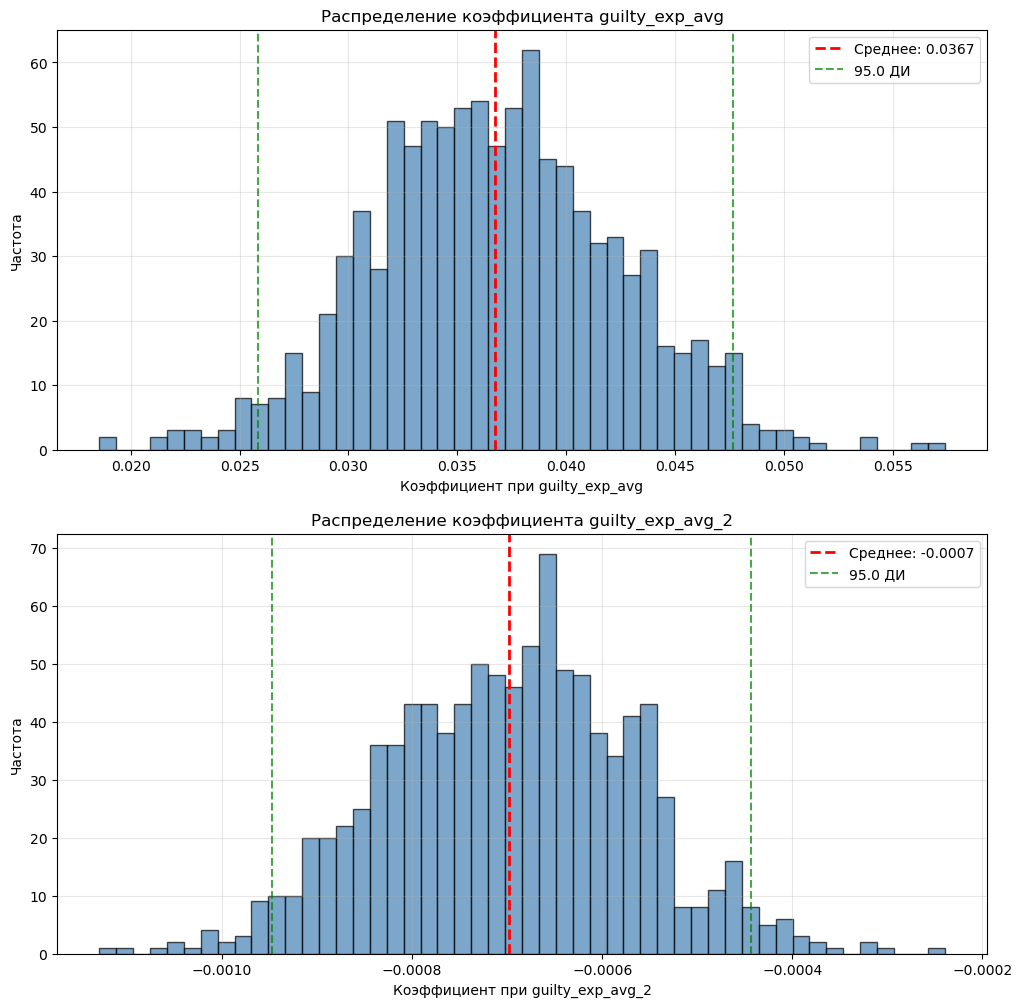

In [160]:

df_agr = data_encoded.copy()
df_agr['guilty_exp_avg'] = data_encoded['guilty_exp_avg']
df_agr['guilty_exp_avg2'] = [i ** 2 for i in data_encoded['guilty_exp_avg']]
df_agr['is_3_4_VEHICLES'] = data_encoded['is_3_4_VEHICLES']

model = sm.Logit
coefs, pvalues, failed_samples = bootstrap(df_agr[['guilty_exp_avg', 'guilty_exp_avg_2', 'YEAR', 'is_WEEKEND',
       'female_driver', 'is_NIGHT', 'maneuver_violation',
       'wrong_way', 'adj_objects_interpretable_LIVING_OBJ',
       'adj_objects_interpretable_ROAD_INFRSTRCT',
       'adj_objects_interpretable_SOCIAL_OBJ',
       'adj_objects_interpretable_TRANSPORT_OBJ', 'road_rank_cat_Другие места',
       'road_rank_cat_Местного значения', 'road_rank_cat_Федеральная',
       'road_rank_cat_Частная']], data_encoded['is_3_4_VEHICLES'], model, 1000, 20000)
stats = bootstrap_stats(coefs, pvalues)
bootstrap_visual(coefs = coefs, cols_visual = ['guilty_exp_avg', 'guilty_exp_avg_2'], stats = stats)

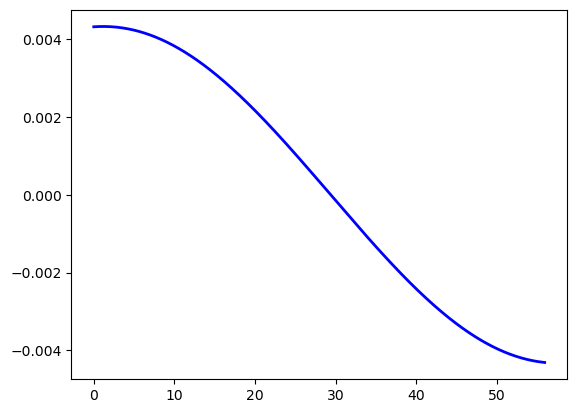

In [169]:
df = df_merge.copy()
df['f'] = (df['n_VEHICLES'] >= 3).astype(int)

a = -0.0008
b = 0.047
c = -2.17
x_range = np.arange(0, df['guilty_exp_avg'].max(), 0.1)
y_range = (1 / (1 + 2.718 ** (-(a*x_range*x_range + b*x_range + c))))*(1 - 1 / (1 + 2.718 ** (-(a*x_range*x_range + b*x_range + c))))*(b + 2*a*x_range)
plt.plot(x_range, y_range, 'b-', linewidth=2)

Text(0, 0.5, 'dole 3-4')

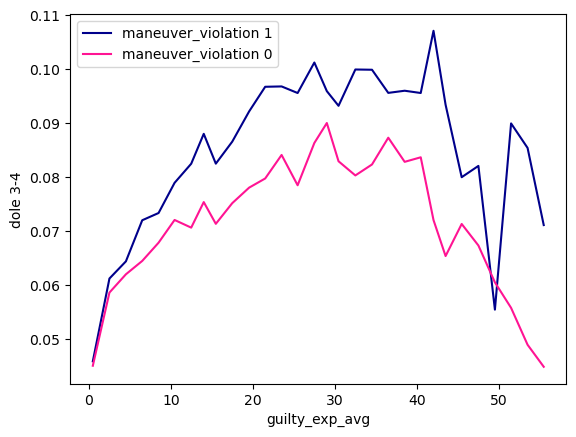

In [163]:
df = df_merge.copy()
n = 30
df['f'] = ((df['n_VEHICLES'] >= 3) & (df['maneuver_violation'] == 1)).astype(int)
df['guilty_exp_avg'] = df['guilty_exp_avg'].astype(int)
df['bin'] = pd.cut(df['guilty_exp_avg'], bins = n)
bn2 = df.groupby('bin').agg(
    dole=('f', 'mean'),
    guilty_avg = ('guilty_exp_avg', lambda x: x.mean())
).reset_index()
plt.figure()
plt.plot(bn2['guilty_avg'], bn2['dole'], label = 'maneuver_violation 1', color = 'darkblue')
df['f'] = ((df['n_VEHICLES'] >= 3) & (df['maneuver_violation'] == 0)).astype(int)
df['guilty_exp_avg'] = df['guilty_exp_avg'].astype(int)
df['bin'] = pd.cut(df['guilty_exp_avg'], bins = n)
bn2 = df.groupby('bin').agg(
    dole=('f', 'mean'),
    guilty_avg = ('guilty_exp_avg', lambda x: x.mean())
).reset_index()
plt.plot(bn2['guilty_avg'], bn2['dole'], label = 'maneuver_violation 0', color = 'DeepPink')
plt.legend()
plt.xlabel('guilty_exp_avg')
plt.ylabel('dole 3-4')

Text(0, 0.5, 'dole 1-2')

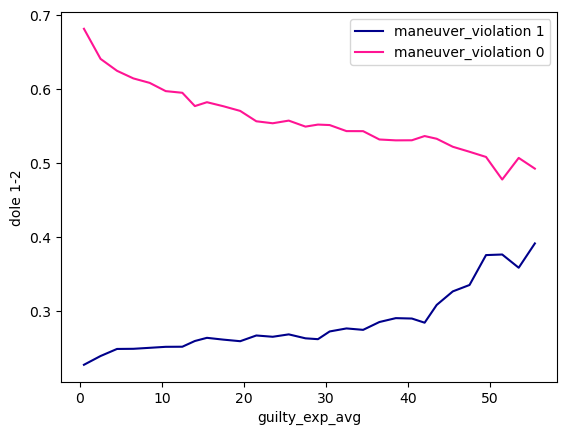

In [165]:
df = df_merge.copy()
n = 30
df['f'] = ((df['n_VEHICLES'] < 3) & (df['maneuver_violation'] == 1)).astype(int)
df['guilty_exp_avg'] = df['guilty_exp_avg'].astype(int)
df['bin'] = pd.cut(df['guilty_exp_avg'], bins = n)
bn2 = df.groupby('bin').agg(
    dole=('f', 'mean'),
    guilty_avg = ('guilty_exp_avg', lambda x: x.mean())
).reset_index()
plt.figure()
plt.plot(bn2['guilty_avg'], bn2['dole'], label = 'maneuver_violation 1', color = 'darkblue')
df['f'] = ((df['n_VEHICLES'] < 3) & (df['maneuver_violation'] == 0)).astype(int)
df['guilty_exp_avg'] = df['guilty_exp_avg'].astype(int)
df['bin'] = pd.cut(df['guilty_exp_avg'], bins = n)
bn2 = df.groupby('bin').agg(
    dole=('f', 'mean'),
    guilty_avg = ('guilty_exp_avg', lambda x: x.mean())
).reset_index()
plt.plot(bn2['guilty_avg'], bn2['dole'], label = 'maneuver_violation 0', color = 'DeepPink')
plt.legend()
plt.xlabel('guilty_exp_avg')
plt.ylabel('dole 1-2')